In [1]:
import numpy as np
from PIL import Image
A = np.fromfile( 'rle.bin', dtype='<u4' )
rows = int(A[0])
columns = int(A[1])
binary_array = ""
option = 0
iters = 0
for i in A[2:]:
        loops = int(i)
        for j in range(0, loops):
            if option == 0:
                binary_array += '0'
            else:
                binary_array += '1'
        if option == 0:
            option = 1
        else:
            option = 0
image = np.zeros((rows, columns))
index = 0
for j in range(0, columns):
    for i in range(0,rows):
            image[i][j] = binary_array[index]
            index += 1
img_colors = (1-image)*255 # 1=black 0=white
img = Image.fromarray(img_colors)
img.show()

Looks like two people-ish things on horses. I do not recognize the characters though.

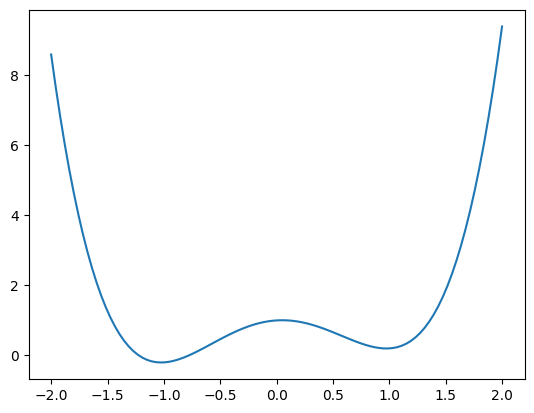

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define the mathematical function
def f(x):
    return ((x**2) - 1)**2 + 0.2 * x
def df(x):
    return 4*x*((x**2)-1)+0.2
x = np.linspace(-2, 2, 100)
y = f(x)
plt.plot(x, y)
plt.show()

In [3]:
def subder(x0, a, M):
    x=x0
    xbest=x0
    fxBest = f(xbest)
    fxBestNotUpdated = 0
    while fxBestNotUpdated < M and (abs(df(x))>10**(-8)):
        g = df(x)
        x = x-(a*g)
        fx = f(x)
        if fx < fxBest:
            xbest = x
            fxBest =fx
        else: fxBestNotUpdated += 1
    return (xbest, fxBest)

In [4]:
subder(1.5, 0.05, 500)

(0.9739943548170674, 0.19743415285827653)

In [5]:
subder(-1.5, 0.05, 500)

(-1.0241203015747595, -0.20244043434482245)

As we are doing the decent they are converging to the local minimums that they start off closer to. So the one starting at 1.5 stays on the right
and converges to the local min on the right. And starting at -1.5 it converges to the minimum closest to that side and stays on the left. 

In [6]:
def f2(x):
    return (x-3)**2

In [7]:
def df2(x):
    return 2*(x-3)

In [8]:

def subder2(x0, a, M):
    x_array = []
    y_array = []
    iteration = 0
    x=x0
    xbest=x0
    fxBest = f2(xbest)
    fxBestNotUpdated = 0
    while fxBestNotUpdated < M and (abs(df2(x))>10**(-8)):
        g = df2(x)
        x = x-(a*g)
        fx = f2(x)
        if fx < fxBest:
            xbest = x
            fxBest =fx
        else: fxBestNotUpdated += 1
        iteration += 1
        x_array.append(iteration)
        y_array.append(fx)
    plt.plot(x_array, y_array)
    plt.show()
    return (xbest, fxBest)

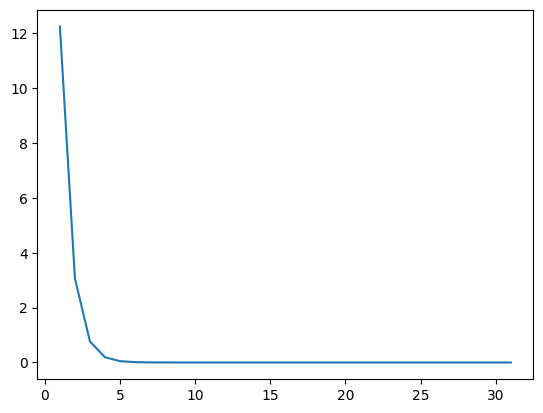

(3.000000003259629, 1.0625181290357943e-17)

In [9]:
subder2(10, 0.25, 25)

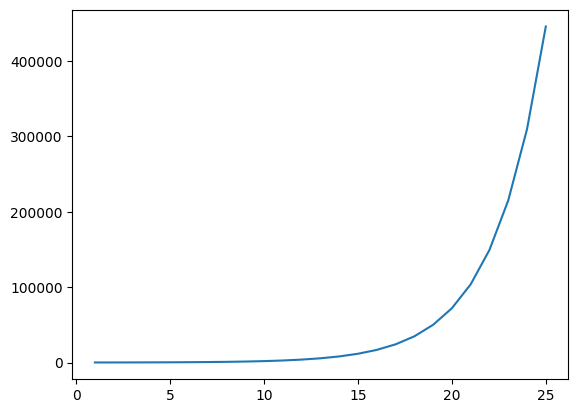

(10, 49)

In [10]:
subder2(10, 1.1, 25)

Since the aplha value was greater than 1, the algortithm cannot converge and instead goes off to infinity.

In [11]:
def armijo_line_search(x, alpha_start=1.1, c=1e-4, rho=0.5):
    a=alpha_start
    g=df2(x)
    while f2(x-(a*g)) > f2(x) - (c*a*g**2):
        a *= rho
    return a

In [16]:
def subder3(x0, a, M):
    x_array = []
    y_array = []
    a_array = []
    iteration = 0
    x=x0
    xbest=x0
    fxBest = f2(xbest)
    fxBestNotUpdated = 0
    while fxBestNotUpdated < M and (abs(df2(x))>10**(-8)):
        g = df2(x)
        x = x-(a*g)
        fx = f2(x)
        if fx < fxBest:
            xbest = x
            fxBest =fx
        else: fxBestNotUpdated += 1
        iteration += 1
        x_array.append(iteration)
        y_array.append(fx)
        a_array.append(a)
        a = armijo_line_search(x, a)
    fig, axs = plt.subplots(1, 2)
    axs[0].plot(x_array, y_array, color='blue')
    axs[1].plot(x_array, a_array, color='orange')
    print(a_array)
    plt.tight_layout()
    plt.show()
    return (xbest, fxBest)

[1.1, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55]


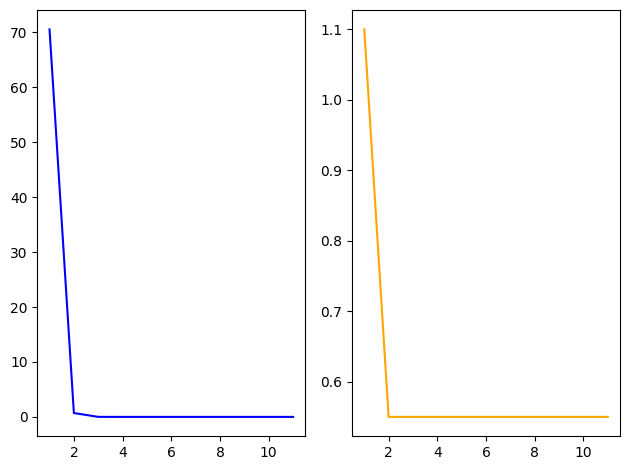

(2.99999999916, 7.056001167632164e-19)

In [17]:
subder3(10, 1.1, 25)

This looks like it is converging to the global minimum

The first value it accepts is 0.55

In [14]:
import random
def get_random_subderivative(x):
    g = 2 * (x - 1)
    if x > -2:
        g += 3
    elif x < -2:
        g -= 3
    else:
        g += random.uniform(-3, 3)
    if x > 2.5:
        g += 2
    elif x < 2.5:
        g -= 2
    else:
        g += random.uniform(-2, 2)
    return g

In [21]:
def bisection_minimize(a, b, tol=1e-6):
    iterations = 0
    while (b - a) > 2 * tol:
        mid = (a + b) / 2.0
        g = get_random_subderivative(mid)
        if g > 0:
            b = mid
        elif g < 0:
            a = mid
        else:
            return mid, iterations
        iterations += 1
    return (a + b) / 2.0, iterations
x_optimal, num_iterations = bisection_minimize(-4, 4, 1e-6)
print(f" x value {x_optimal}")
print(f" iterations {num_iterations}")

 x value 0.5
 iterations 3
